In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/computervisionimgs/test2.jpg
/kaggle/input/computervisionimgs/test1.jpeg


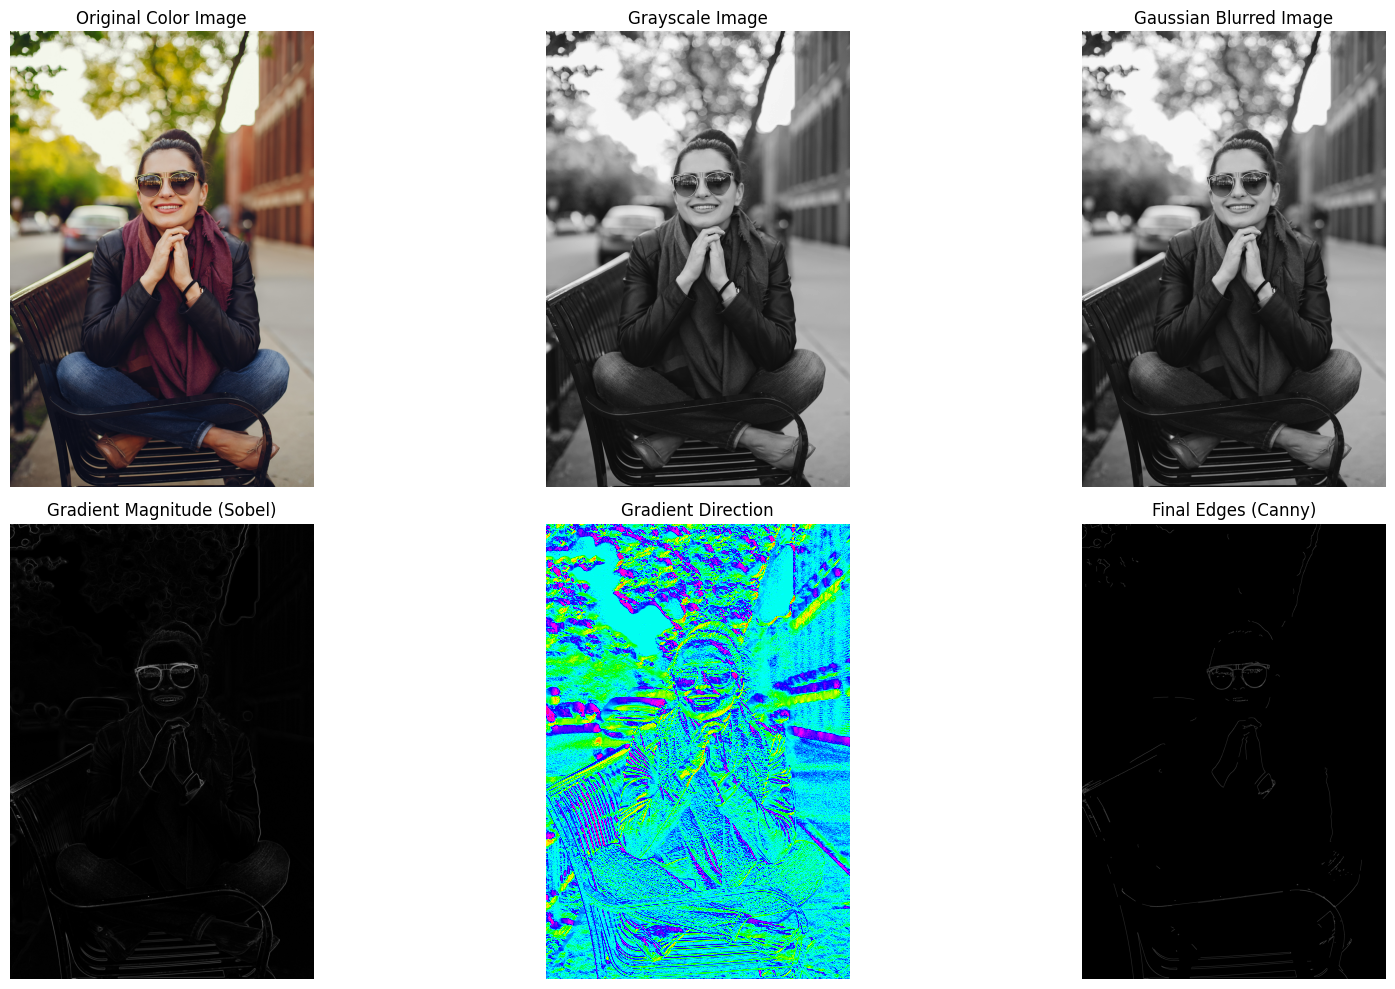

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the color image
image_path = "/kaggle/input/computervisionimgs/beautiful-young-girl-leather-jacket-scarf-sitting-streets-chicago.jpg"
color_image = cv2.imread(image_path)

# 1️⃣ Convert to grayscale
gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

# 2️⃣ Apply Gaussian Blur (noise reduction)
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 1.4)

# 3️⃣ Compute gradients using Sobel filters
grad_x = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)

# Gradient magnitude and direction
magnitude = np.sqrt(grad_x**2 + grad_y**2)
magnitude = np.uint8(255 * magnitude / np.max(magnitude))  # normalize for display
direction = np.arctan2(grad_y, grad_x)

# 4️⃣ Non-maximum suppression (handled internally in Canny, but we’ll skip visualization for now)

# 5️⃣ Apply Canny Edge Detection
edges = cv2.Canny(blurred_image, 100, 200)

# 🎨 Plot all the stages
plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
plt.title("Original Color Image")
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,2)
plt.title("Grayscale Image")
plt.imshow(gray_image, cmap="gray")
plt.axis("off")

plt.subplot(2,3,3)
plt.title("Gaussian Blurred Image")
plt.imshow(blurred_image, cmap="gray")
plt.axis("off")

plt.subplot(2,3,4)
plt.title("Gradient Magnitude (Sobel)")
plt.imshow(magnitude, cmap="gray")
plt.axis("off")

plt.subplot(2,3,5)
plt.title("Gradient Direction")
plt.imshow(direction, cmap="hsv")
plt.axis("off")

plt.subplot(2,3,6)
plt.title("Final Edges (Canny)")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


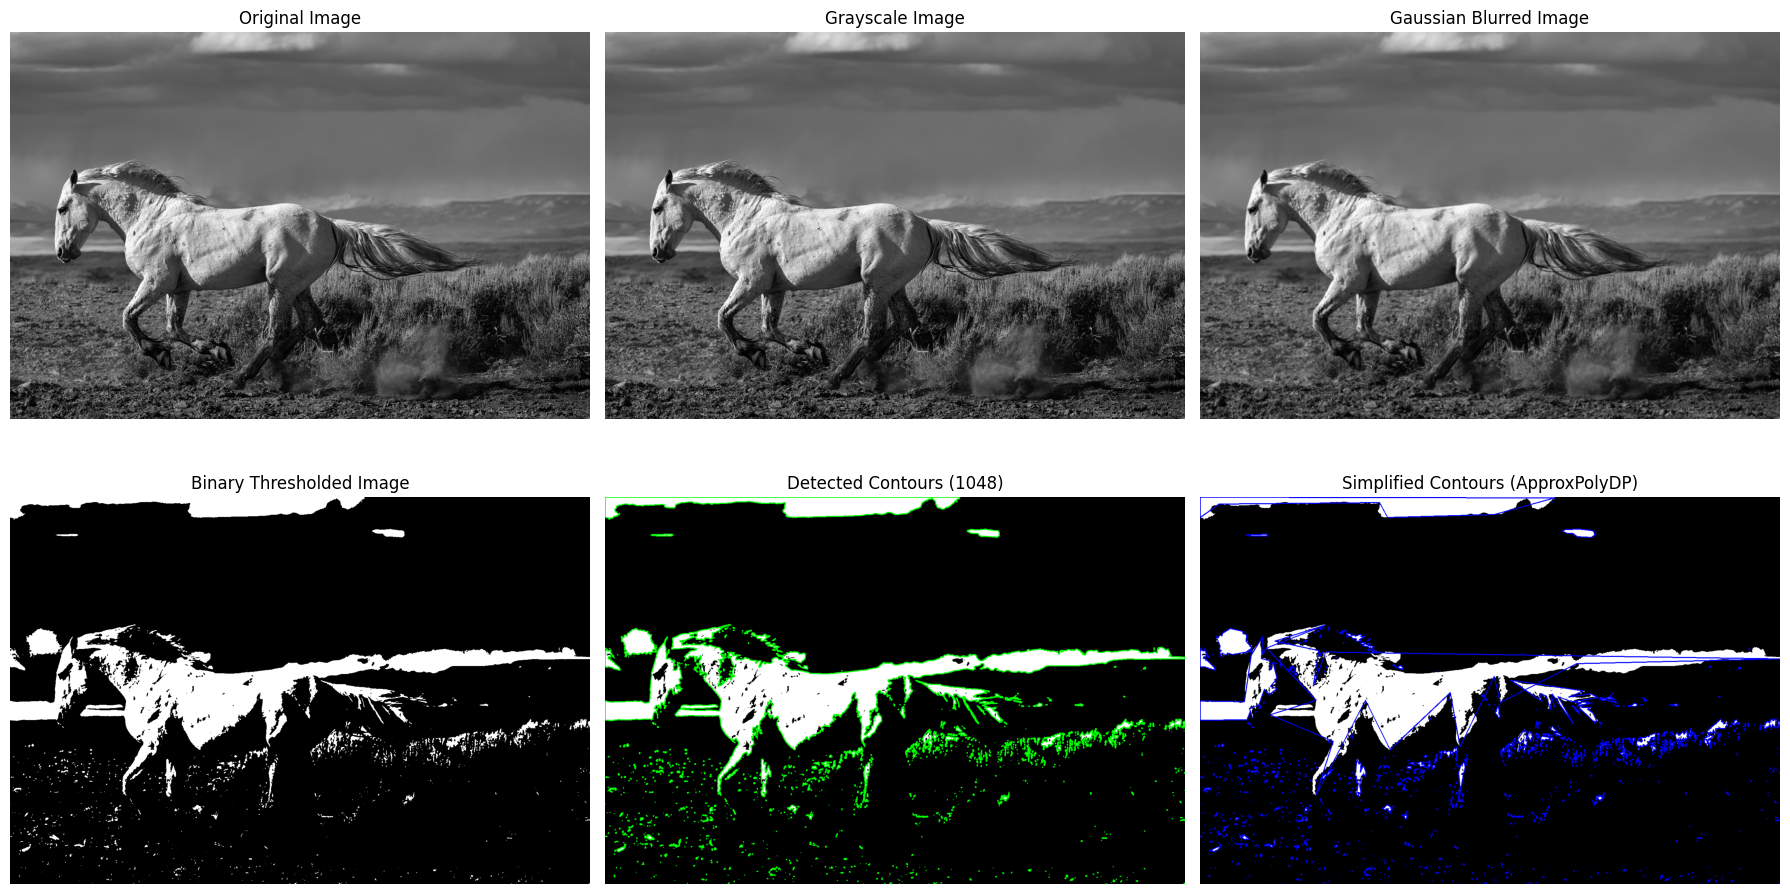

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = "/kaggle/input/computervisionimgs/test2.jpg"  # change path to your image
image = cv2.imread(image_path)

# 1️⃣ Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 2️⃣ Apply Gaussian Blur (optional but helps remove noise)
blurred = cv2.GaussianBlur(gray, (5,5), 1)

# 3️⃣ Thresholding to make the image Binary
#    Pixels >127 → white (255), else → black (0)
_, binary = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

# 4️⃣ Find Contours (external only to avoid nested ones)
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 5️⃣ Draw All Contours
output_all = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
cv2.drawContours(output_all, contours, -1, (0,255,0), 2)

# 6️⃣ Approximate & Draw Simplified Contours
output_simplified = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
for cnt in contours:
    epsilon = 0.01 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    cv2.drawContours(output_simplified, [approx], -1, (255,0,0), 2)

# 🎨 Show all stages
plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Gaussian Blurred Image")
plt.imshow(blurred, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Binary Thresholded Image")
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title(f"Detected Contours ({len(contours)})")
plt.imshow(cv2.cvtColor(output_all, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Simplified Contours (ApproxPolyDP)")
plt.imshow(cv2.cvtColor(output_simplified, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()


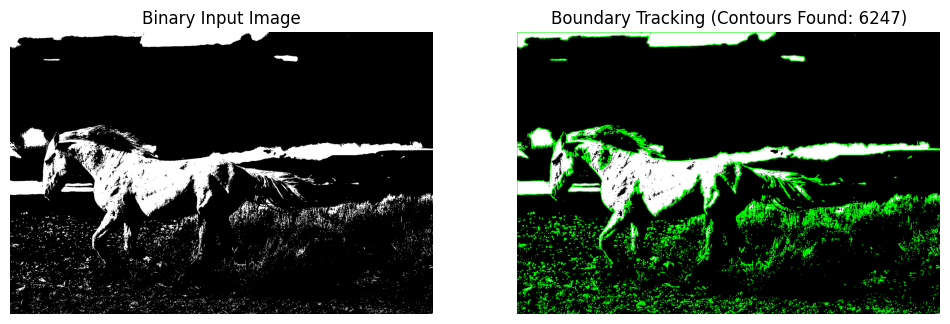

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the black-and-white (binary) image
image_path = "/kaggle/input/computervisionimgs/test2.jpg"  # change path to your file
bw = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Ensure it’s binary
_, binary = cv2.threshold(bw, 127, 255, cv2.THRESH_BINARY)

# Find contours (boundaries)
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create an output image (convert to color for drawing)
output = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

# Draw all contours in green
cv2.drawContours(output, contours, -1, (0, 255, 0), 2)

# Display results
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Binary Input Image")
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f"Boundary Tracking (Contours Found: {len(contours)})")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()





In [ ]:
|